# 2. Runtime-BAL decomposition and parent-activity demand

This notebook reproduces the transaction-level BAL decomposition and the
parent-price demand specification in
`markdowns/bundle_priced_bal_demand_model_report.md`.

The same 6,000 deterministic blocks used by notebook 01 are reconstructed at
transaction level. Every byte is assigned to direct state creation,
co-produced access in a state-creating transaction, or a transaction with no
observed state creation. The unresolved behavioral routing of co-produced
access is retained as the structural parameter $\lambda$.


## Transaction-level refresh

With `REFRESH_7999_FROM_NETWORK=1`, the notebook runs the resumable Xatu
attribution builder. It queries structlog aggregates, storage diffs, traces,
state-creation inputs, and transaction gas inputs in bounded chunks. Cached
blocks are reused on restart.


In [1]:
from pathlib import Path
import os
import subprocess
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise RuntimeError("Could not locate the repository root")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data"
OUT_DIR = DATA_DIR / "7999"
PLOT_DIR = PROJECT_ROOT / "plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

START_DATE = "2026-02-01"
END_DATE = "2026-06-01"
DATE_TAG = f"{START_DATE}_{END_DATE}"
REFRESH_FROM_NETWORK = os.environ.get("REFRESH_7999_FROM_NETWORK", "0") == "1"

RUNTIME_BLOCK_CSV = DATA_DIR / f"calibration_xatu_bal_runtime_8279_blocks_{DATE_TAG}.csv"
ATTRIBUTION_BLOCK_CSV = DATA_DIR / f"calibration_xatu_bal_runtime_8279_state_execution_blocks_{DATE_TAG}.csv"
METERING_ANCHOR_CSV = OUT_DIR / "data_metering_runtime_bal_anchor.csv"
OUT_COMPONENTS_CSV = OUT_DIR / "bal_runtime_component_attribution.csv"
OUT_TWO_WAY_CSV = OUT_DIR / "bal_runtime_two_way_decomposition.csv"
OUT_THREE_WAY_CSV = OUT_DIR / "bal_runtime_three_way_decomposition.csv"
OUT_THREE_WAY_COMPONENTS_CSV = OUT_DIR / "bal_runtime_three_way_components.csv"
OUT_INTENSITIES_CSV = OUT_DIR / "bal_intensities.csv"
OUT_DEMAND_CARD_CSV = OUT_DIR / "bal_decomposition_demand_parameters.csv"
OUT_DATA_RESPONSE_CSV = OUT_DIR / "bal_data_demand_response.csv"
OUT_SAMPLING_CSV = OUT_DIR / "bal_sampling_uncertainty.csv"
COUPLING_PLOT = PLOT_DIR / f"bal_state_creation_coupling_calibration_{DATE_TAG}.png"
THREE_WAY_COMPONENT_PLOT = PLOT_DIR / f"bal_runtime_8279_three_way_components_{DATE_TAG}.png"
DATA_RESPONSE_PLOT = PLOT_DIR / f"bal_data_demand_response_{DATE_TAG}.png"

plt.rcParams.update({
    "font.size": 14, "axes.titlesize": 16, "axes.labelsize": 14,
    "xtick.labelsize": 13, "ytick.labelsize": 13, "legend.fontsize": 13,
})

if REFRESH_FROM_NETWORK:
    subprocess.run(
        [sys.executable, str(PROJECT_ROOT / "scripts" / "build_bal_runtime_state_attribution.py")],
        cwd=PROJECT_ROOT,
        check=True,
    )

required = [RUNTIME_BLOCK_CSV, ATTRIBUTION_BLOCK_CSV, METERING_ANCHOR_CSV]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing notebook-01 handoff or Xatu attribution cache:\n- "
        + "\n- ".join(missing)
    )

runtime_blocks = pd.read_csv(RUNTIME_BLOCK_CSV)
attribution_blocks = pd.read_csv(ATTRIBUTION_BLOCK_CSV)
metering_anchor = pd.read_csv(METERING_ANCHOR_CSV).iloc[0]
RUNTIME_ANCHOR = float(metering_anchor["runtime_bal_bytes_per_block"])
RUNTIME_DATA_GAS_16 = float(metering_anchor["runtime_bal_data_gas_per_block"])

assert runtime_blocks["block_number"].nunique() == 6_000
assert attribution_blocks["block_number"].nunique() == 6_000
validation = runtime_blocks[["block_number", "bal_runtime_bytes_8279"]].merge(
    attribution_blocks[["block_number", "bal_runtime_bytes_8279"]],
    on="block_number", how="inner", validate="one_to_one",
    suffixes=("_block", "_transaction"),
)
validation["difference"] = (
    validation["bal_runtime_bytes_8279_block"]
    - validation["bal_runtime_bytes_8279_transaction"]
)
assert validation["difference"].eq(0).all()
pd.DataFrame([{
    "validation_blocks": len(validation),
    "exact_matches": int(validation["difference"].eq(0).sum()),
    "mean_absolute_difference_bytes": validation["difference"].abs().mean(),
}])


,validation_blocks,exact_matches,mean_absolute_difference_bytes
0,6000,6000,0.0


## State- and execution-linked runtime BAL

The full 6,000-block transaction panel is used to separate the runtime meter into two components:

$$
M_{\mathrm{BAL}}=M_{\mathrm{state}}+M_{\mathrm{execution}}.
$$

- $M_{\mathrm{state}}$ contains runtime bytes matched directly to new storage slots, new accounts, or deployed code.
- $M_{\mathrm{execution}}$ contains the remaining runtime bytes, including existing-state access and other EIP-8279 events not matched directly to persistent state creation.

New storage slots are matched to cold storage-key and changed-value events. New accounts are matched to creation, cold-account, and value-transfer events. Deployed code is matched directly to runtime code bytes. Xatu's aggregated structlogs do not preserve the target address or storage key for each cold-access count, so cold key, account, and balance matches are capped within each transaction. The state-linked result is therefore a reproducible matched estimate rather than exact address-level attribution.

The execution suffix is model notation for the second component because total execution is used as state-access activity proxy. It does not mean that every byte in $M_{\mathrm{execution}}$ is mechanically generated by execution gas.

In [2]:
daily_attribution = (
    attribution_blocks.groupby('date', as_index=False)
    .agg(
        runtime_bytes=('bal_runtime_bytes_8279', 'sum'),
        state_bytes=('bal_runtime_bytes_state_8279', 'sum'),
        execution_bytes=('bal_runtime_bytes_execution_8279', 'sum'),
        sampled_blocks=('block_number', 'size'),
    )
)
daily_attribution['state_weight'] = (
    daily_attribution['state_bytes'] / daily_attribution['runtime_bytes']
)
daily_attribution['execution_weight'] = (
    daily_attribution['execution_bytes'] / daily_attribution['runtime_bytes']
)

TOTAL_RUNTIME_BYTES = int(attribution_blocks['bal_runtime_bytes_8279'].sum())
STATE_RUNTIME_BYTES = int(attribution_blocks['bal_runtime_bytes_state_8279'].sum())
EXECUTION_RUNTIME_BYTES = int(attribution_blocks['bal_runtime_bytes_execution_8279'].sum())
COPRODUCED_RUNTIME_BYTES = int(
    attribution_blocks['bal_runtime_bytes_coproduced_state_txs_8279'].sum()
)
NONSTATE_RUNTIME_BYTES = int(
    attribution_blocks['bal_runtime_bytes_nonstate_txs_8279'].sum()
)
STATE_WEIGHT = STATE_RUNTIME_BYTES / TOTAL_RUNTIME_BYTES
EXECUTION_WEIGHT = EXECUTION_RUNTIME_BYTES / TOTAL_RUNTIME_BYTES
COPRODUCED_WEIGHT = COPRODUCED_RUNTIME_BYTES / TOTAL_RUNTIME_BYTES
NONSTATE_WEIGHT = NONSTATE_RUNTIME_BYTES / TOTAL_RUNTIME_BYTES
STATE_BUNDLE_WEIGHT = STATE_WEIGHT + COPRODUCED_WEIGHT
TRANSACTION_COUNT = int(attribution_blocks['transactions'].sum())
STATE_TRANSACTION_COUNT = int(attribution_blocks['state_transactions'].sum())
DIRECT_STATE_TRANSACTION_COUNT = int(
    attribution_blocks['direct_state_transactions'].sum()
)
STATE_TRANSACTION_SHARE = STATE_TRANSACTION_COUNT / TRANSACTION_COUNT
DIRECT_STATE_TRANSACTION_SHARE = DIRECT_STATE_TRANSACTION_COUNT / TRANSACTION_COUNT

two_way = pd.DataFrame([
    {'component': 'state-linked', 'runtime_bytes': STATE_RUNTIME_BYTES, 'share': STATE_WEIGHT},
    {'component': 'execution-linked (access proxy)', 'runtime_bytes': EXECUTION_RUNTIME_BYTES, 'share': EXECUTION_WEIGHT},
])
two_way.to_csv(OUT_TWO_WAY_CSV, index=False)

three_way = pd.DataFrame([
    {'component': 'matched direct state', 'runtime_bytes': STATE_RUNTIME_BYTES, 'share': STATE_WEIGHT},
    {'component': 'co-produced in state-creating transactions', 'runtime_bytes': COPRODUCED_RUNTIME_BYTES, 'share': COPRODUCED_WEIGHT},
    {'component': 'transactions with no observed state creation', 'runtime_bytes': NONSTATE_RUNTIME_BYTES, 'share': NONSTATE_WEIGHT},
])
three_way.to_csv(OUT_THREE_WAY_CSV, index=False)
three_way

,component,runtime_bytes,share
0,matched direct state,81996613,0.113937
1,co-produced in state-creating transactions,272602784,0.378791
2,transactions with no observed state creation,365066264,0.507272


In [3]:
component_specs = [
    ('storage key', ['storage_key_bytes_8279'], ['direct_new_storage_key_bytes_8279']),
    ('storage value', ['storage_value_bytes_8279_observed'], ['direct_new_storage_value_bytes_8279']),
    ('account access', ['account_access_bytes_8279'], ['direct_new_account_access_bytes_8279']),
    (
        'value transfer',
        ['balance_call_bytes_8279', 'balance_selfdestruct_bytes_8279', 'create_endowment_bytes_8279'],
        ['direct_new_account_balance_bytes_8279', 'direct_create_endowment_bytes_8279'],
    ),
    (
        'contract creation',
        ['create_address_bytes_8279', 'create_nonce_bytes_8279'],
        ['direct_create_address_bytes_8279', 'direct_create_nonce_bytes_8279'],
    ),
    ('deployed code', ['deployed_code_bytes_8279'], ['direct_deployed_code_bytes_8279']),
]
component_rows = []
for component, total_columns, state_columns in component_specs:
    runtime_bytes = int(attribution_blocks[total_columns].sum().sum())
    state_bytes = int(attribution_blocks[state_columns].sum().sum())
    component_rows.append({
        'component': component,
        'runtime_bytes': runtime_bytes,
        'state_bytes': state_bytes,
        'execution_bytes': runtime_bytes - state_bytes,
        'share_of_runtime_bytes': runtime_bytes / TOTAL_RUNTIME_BYTES,
        'state_share_within_component': state_bytes / runtime_bytes if runtime_bytes else np.nan,
    })
components = pd.DataFrame(component_rows)
assert components['runtime_bytes'].sum() == TOTAL_RUNTIME_BYTES
assert components['state_bytes'].sum() == STATE_RUNTIME_BYTES
components.to_csv(OUT_COMPONENTS_CSV, index=False)

component_prefixes = {
    'storage key': 'storage_key',
    'storage value': 'storage_value',
    'account access': 'account_access',
    'value transfer': 'value_transfer',
    'contract creation': 'contract_creation',
    'deployed code': 'deployed_code',
}
three_way_component_rows = []
for component, prefix in component_prefixes.items():
    direct = int(attribution_blocks[f'{prefix}_bytes_direct_state_8279'].sum())
    coproduced = int(attribution_blocks[f'{prefix}_bytes_coproduced_state_txs_8279'].sum())
    nonstate = int(attribution_blocks[f'{prefix}_bytes_nonstate_txs_8279'].sum())
    three_way_component_rows.append({
        'component': component,
        'direct_state_bytes': direct,
        'coproduced_state_transaction_bytes': coproduced,
        'nonstate_transaction_bytes': nonstate,
        'runtime_bytes': direct + coproduced + nonstate,
    })
three_way_components = pd.DataFrame(three_way_component_rows)
for column in ['direct_state_bytes', 'coproduced_state_transaction_bytes', 'nonstate_transaction_bytes']:
    three_way_components[f'{column}_share_total'] = three_way_components[column] / TOTAL_RUNTIME_BYTES
    three_way_components[f'{column}_share_component'] = three_way_components[column] / three_way_components['runtime_bytes']
assert three_way_components['runtime_bytes'].sum() == TOTAL_RUNTIME_BYTES
assert three_way_components['direct_state_bytes'].sum() == STATE_RUNTIME_BYTES
assert three_way_components['coproduced_state_transaction_bytes'].sum() == COPRODUCED_RUNTIME_BYTES
assert three_way_components['nonstate_transaction_bytes'].sum() == NONSTATE_RUNTIME_BYTES
three_way_components.to_csv(OUT_THREE_WAY_COMPONENTS_CSV, index=False)
three_way_components

,component,direct_state_bytes,coproduced_state_transaction_bytes,nonstate_transaction_bytes,runtime_bytes,direct_state_bytes_share_total,direct_state_bytes_share_component,coproduced_state_transaction_bytes_share_total,coproduced_state_transaction_bytes_share_component,nonstate_transaction_bytes_share_total,nonstate_transaction_bytes_share_component
0,storage key,33140352,183420608,243991744,460552704,0.046050,0.071958,0.254869,0.398262,0.339035,0.529780
1,storage value,33546688,52186304,83043776,168776768,0.046614,0.198764,0.072515,0.309203,0.115392,0.492033
2,account access,974820,23523420,26638260,51136500,0.001355,0.019063,0.032687,0.460012,0.037015,0.520925
3,value transfer,3800480,13425216,11383776,28609472,0.005281,0.132840,0.018655,0.469258,0.015818,0.397902
4,contract creation,1202824,47236,8708,1258768,0.001671,0.955557,0.000066,0.037526,0.000012,0.006918
5,deployed code,9331449,0,0,9331449,0.012966,1.000000,0.000000,0.000000,0.000000,0.000000


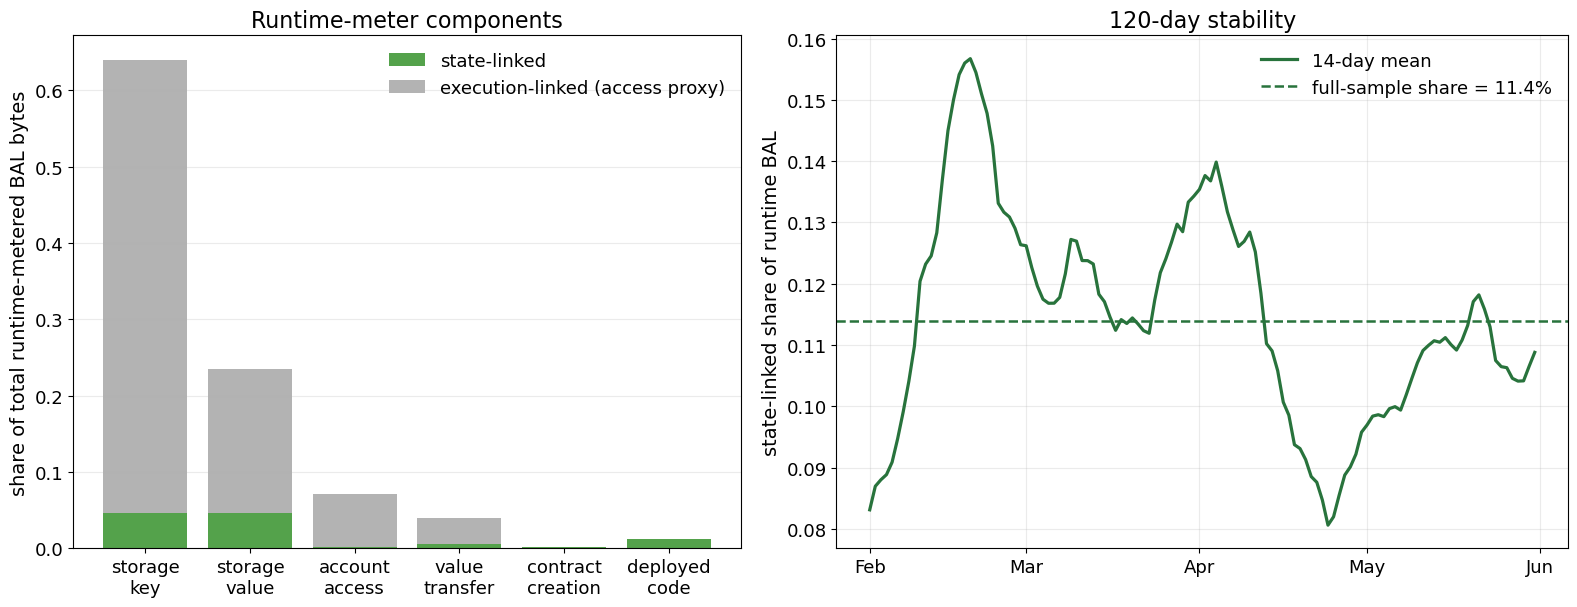

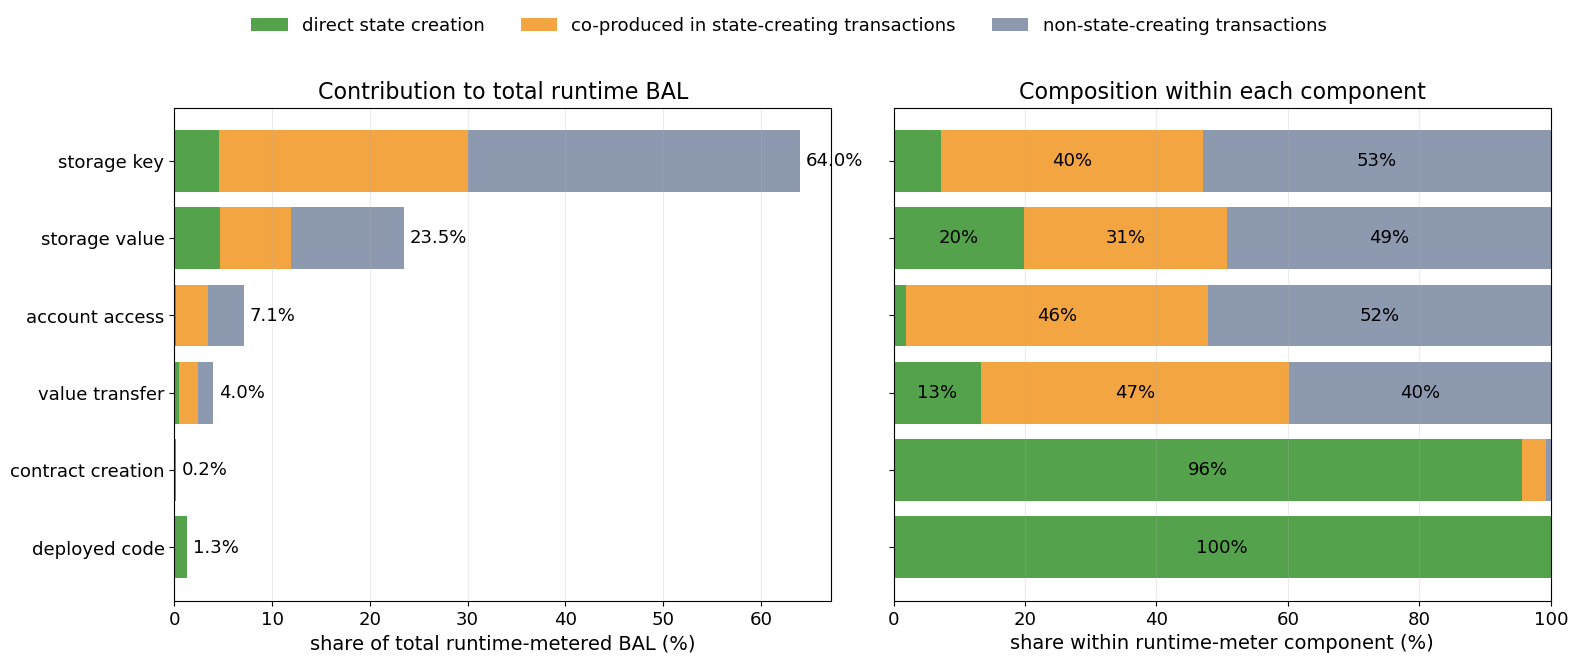

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16.0, 6.3), gridspec_kw={'width_ratios': [1.05, 1.15]})
x = np.arange(len(components))
state_share = components['state_bytes'] / TOTAL_RUNTIME_BYTES
execution_share = components['execution_bytes'] / TOTAL_RUNTIME_BYTES
axes[0].bar(x, state_share, color='#54a24b', label='state-linked')
axes[0].bar(
    x, execution_share, bottom=state_share, color='#b3b3b3',
    label='execution-linked (access proxy)',
)
axes[0].set_xticks(x, ['storage\nkey', 'storage\nvalue', 'account\naccess', 'value\ntransfer', 'contract\ncreation', 'deployed\ncode'])
axes[0].set_ylabel('share of total runtime-metered BAL bytes')
axes[0].set_title('Runtime-meter components')
axes[0].legend(frameon=False, loc='upper right')
axes[0].grid(axis='y', alpha=0.25)

daily_plot = daily_attribution.copy()
daily_plot['date'] = pd.to_datetime(daily_plot['date'])
rolling_state = daily_plot.set_index('date')['state_weight'].rolling(
    14, center=True, min_periods=7
).mean()
axes[1].plot(rolling_state.index, rolling_state, color='#28733c', linewidth=2.3, label='14-day mean')
axes[1].axhline(
    STATE_WEIGHT, color='#28733c', linestyle='--', linewidth=1.8,
    label=f'full-sample share = {STATE_WEIGHT:.1%}',
)
axes[1].set_ylabel('state-linked share of runtime BAL')
axes[1].set_title('120-day stability')
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.25)
fig.tight_layout()
fig.savefig(COUPLING_PLOT, dpi=220, bbox_inches='tight')
plt.show()

category_columns = [
    'direct_state_bytes',
    'coproduced_state_transaction_bytes',
    'nonstate_transaction_bytes',
]
category_labels = [
    'direct state creation',
    'co-produced in state-creating transactions',
    'non-state-creating transactions',
]
category_colors = ['#54a24b', '#f2a541', '#8d99ae']
y = np.arange(len(three_way_components))
fig, axes = plt.subplots(1, 2, figsize=(16.0, 6.6), sharey=True)

left = np.zeros(len(three_way_components))
for column, label, color in zip(category_columns, category_labels, category_colors):
    values = 100 * three_way_components[column] / TOTAL_RUNTIME_BYTES
    axes[0].barh(y, values, left=left, color=color, label=label)
    left += values
for row, total_share in enumerate(left):
    axes[0].text(total_share + 0.6, row, f'{total_share:.1f}%', va='center', fontsize=13)
axes[0].set_xlabel('share of total runtime-metered BAL (%)')
axes[0].set_title('Contribution to total runtime BAL')
axes[0].set_yticks(y, three_way_components['component'])
axes[0].grid(axis='x', alpha=0.25)

left = np.zeros(len(three_way_components))
for column, label, color in zip(category_columns, category_labels, category_colors):
    values = 100 * three_way_components[column] / three_way_components['runtime_bytes']
    axes[1].barh(y, values, left=left, color=color, label=label)
    for row, (start, value) in enumerate(zip(left, values)):
        if value >= 8:
            axes[1].text(start + value / 2, row, f'{value:.0f}%', ha='center', va='center', fontsize=13)
    left += values
axes[1].set_xlim(0, 100)
axes[1].set_xlabel('share within runtime-meter component (%)')
axes[1].set_title('Composition within each component')
axes[1].grid(axis='x', alpha=0.25)
axes[0].invert_yaxis()
fig.legend(*axes[1].get_legend_handles_labels(), frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(THREE_WAY_COMPONENT_PLOT, dpi=220, bbox_inches='tight')
plt.show()

## Central BAL demand model

Let $B_t$ denote EIP-8279 runtime-metered BAL bytes, $S_t$ persistent state-creation activity, and $A_t$ existing-state access activity. Define $w_{\mathrm{state}}$ and $w_{\mathrm{execution}}=1-w_{\mathrm{state}}$ as the two runtime-meter weights. The central model is

$$
\frac{B_t}{B_0}
=w_{\mathrm{state}}\frac{S_t}{S_0}
+w_{\mathrm{execution}}\frac{A_t}{A_0}.
$$

The 6,000-block estimates are $w_{\mathrm{state}}=0.113937$ and $w_{\mathrm{execution}}=0.886063$.

The wider historical panel does not contain an independently priced state-access quantity. Total execution activity is therefore used as a proxy:

$$
\frac{A_t}{A_0}
\approx
\left(\frac{E_t}{E_0}\right)^{\rho_A},
\qquad \rho_A=1.
$$

The central benchmark is therefore

$$
\frac{B_t}{B_0}
=0.113937\frac{S_t}{S_0}
+0.886063\frac{E_t}{E_0}.
$$

The execution-linked component is not empirically shown to follow execution demand. Total execution is a reduced-form proxy for state-access activity, and $\rho_A=1$ assumes that access intensity remains constant as execution scales.

The same 6,000-block panel provides a transaction-bundle diagnostic. Directly matched state creation contributes 11.39% of runtime BAL, access co-produced inside state-creating transactions contributes 37.88%, and transactions with no observed state creation contribute 50.73%. If $\lambda$ is the share of co-produced access assigned to state activity, then

$$
w_{\mathrm{state}}(\lambda)=0.113937+0.378791\lambda.
$$

The central model sets $\lambda=0$, so only bytes directly matched to created objects follow $S_t$. The co-produced pool establishes exposure to state-creating transactions, not its behavioral response to the state fee; the aggregate state elasticity does not identify how those transaction bundles exit.

## BAL intensities and bundle-priced parent demand

BAL has no independent demand curve. A historical unit of execution activity
pays $m_{\mathrm{execution}} b_{\mathrm{execution}} + w_{\mathrm{execution}} b_{\mathrm{data}}$,
and a historical unit of state activity pays
$m_{\mathrm{state}} b_{\mathrm{state}} + w_{\mathrm{state}} b_{\mathrm{data}}$.
The measured shares determine $w_{\mathrm{execution}}(\lambda)$ and
$w_{\mathrm{state}}(\lambda)$; the parent elasticities determine the response.


In [5]:
# The execution/state activity anchors and metering multipliers are derived in
# ../resource_demand_and_glamsterdam_equilibrium/02-metering-multipliers.ipynb.
# If its handoff is present, verify and use it; otherwise
# use the exact published input values carried into the two EIP-7999 reports.
published_shared_anchor = {
    "base_fee_ref_gwei": 0.1069278435,
    "q_execution_per_block": 23_942_241.363434453,
    "q_state_per_block": 5_244_154.703798162,
    "m_execution": 1.5378980217571416,
    "m_state": 5.656315259465248,
}
glam_anchor_path = DATA_DIR / "glamsterdam" / "equilibrium_anchor.csv"
if glam_anchor_path.exists():
    shared = pd.read_csv(glam_anchor_path).iloc[0]
    shared_anchor = {
        "base_fee_ref_gwei": float(shared["base_fee_ref_gwei"]),
        "q_execution_per_block": float(shared["q_execution_per_block"]),
        "q_state_per_block": float(shared["q_state_per_block"]),
        "m_execution": float(shared["m_execution"]),
        "m_state": float(shared["m_state"]),
    }
    for key, value in published_shared_anchor.items():
        if not np.isclose(shared_anchor[key], value, rtol=2e-10, atol=1e-9):
            raise AssertionError(f"shared Glamsterdam anchor changed for {key}")
else:
    shared_anchor = published_shared_anchor

q_execution_0 = shared_anchor["q_execution_per_block"]
q_state_0 = shared_anchor["q_state_per_block"]
m_execution = shared_anchor["m_execution"]
m_state = shared_anchor["m_state"]
g_bal_0 = RUNTIME_DATA_GAS_16

intensity_rows = []
for lambda_bal in (0.0, 0.5, 1.0):
    state_share = STATE_WEIGHT + lambda_bal * COPRODUCED_WEIGHT
    execution_share = NONSTATE_WEIGHT + (1.0 - lambda_bal) * COPRODUCED_WEIGHT
    w_execution = execution_share * g_bal_0 / q_execution_0
    w_state = state_share * g_bal_0 / q_state_0
    intensity_rows.append({
        "lambda_bal": lambda_bal,
        "execution_runtime_share": execution_share,
        "state_runtime_share": state_share,
        "w_execution": w_execution,
        "w_state": w_state,
        "w_execution_over_m_execution": w_execution / m_execution,
        "w_state_over_m_state": w_state / m_state,
    })
intensities = pd.DataFrame(intensity_rows)
intensities.to_csv(OUT_INTENSITIES_CSV, index=False)
display(intensities)

central = intensities[intensities["lambda_bal"].eq(0.0)].iloc[0]
demand_card = pd.DataFrame([{
    **shared_anchor,
    "runtime_bal_data_gas_per_block": g_bal_0,
    "bal_direct_state_weight": STATE_WEIGHT,
    "bal_coproduced_state_transaction_weight": COPRODUCED_WEIGHT,
    "bal_nonstate_transaction_weight": NONSTATE_WEIGHT,
    "lambda_bal_reference": 0.0,
    "rho_A_reference": 1.0,
    "w_execution_reference": central["w_execution"],
    "w_state_reference": central["w_state"],
    "w_execution_over_m_execution": central["w_execution_over_m_execution"],
    "w_state_over_m_state": central["w_state_over_m_state"],
    "runtime_block_transaction_exact_match_share": validation["difference"].eq(0).mean(),
}])
demand_card.to_csv(OUT_DEMAND_CARD_CSV, index=False)

assert np.isclose(STATE_WEIGHT, 0.113937, rtol=5e-6)
assert np.isclose(COPRODUCED_WEIGHT, 0.378791, rtol=5e-6)
assert np.isclose(NONSTATE_WEIGHT, 0.507272, rtol=5e-6)
assert np.isclose(central["w_execution"], 0.071023, rtol=1e-5)
assert np.isclose(central["w_state"], 0.041695, rtol=1e-5)
display(demand_card.T)
print("wrote", OUT_DEMAND_CARD_CSV.relative_to(PROJECT_ROOT))


,lambda_bal,execution_runtime_share,state_runtime_share,w_execution,w_state,w_execution_over_m_execution,w_state_over_m_state
0,0.0,0.886063,0.113937,0.071023,0.041695,0.046182,0.007371
1,0.5,0.696667,0.303333,0.055842,0.111005,0.036310,0.019625
2,1.0,0.507272,0.492728,0.040661,0.180314,0.026439,0.031878


,0
base_fee_ref_gwei,1.069278e-01
q_execution_per_block,2.394224e+07
q_state_per_block,5.244155e+06
m_execution,1.537898e+00
m_state,5.656315e+00
runtime_bal_data_gas_per_block,1.919100e+06
bal_direct_state_weight,1.139371e-01
bal_coproduced_state_transaction_weight,3.787909e-01
bal_nonstate_transaction_weight,5.072720e-01
lambda_bal_reference,0.000000e+00


wrote data/7999/bal_decomposition_demand_parameters.csv


## What the model predicts for data demand

The sections above give the mechanism. This one shows its size.

This is an illustrative **partial-equilibrium diagnostic**, not a solved
EIP-7999 equilibrium. Notebook 03 solves the three fees jointly.

Execution and state fees are held at their anchor-equivalent values
$b_{\mathrm{execution}}=p^0/m_{\mathrm{execution}}$ and
$b_{\mathrm{state}}=p^0/m_{\mathrm{state}}$, so that only the data fee moves and
the feedback channel is isolated. Two specifications are swept:

- **No feedback.** Parents are priced without the BAL term, so execution and
  state stay at their anchors and runtime BAL is fixed at $g_{\mathrm{BAL}}^0$.
  Only static data responds to $b_{\mathrm{data}}$.
- **Bundle-priced.** Parents pay $m_i b_i + w_i b_{\mathrm{data}}$, so a higher
  data fee contracts execution and state, and BAL contracts with them.

The gap between the two totals is the whole of the feedback effect. The two must
converge as $b_{\mathrm{data}}\to0$, where the BAL surcharge vanishes.

The right panel varies $\lambda$ and $\rho_A$, the two allocation assumptions not
identified by historical variation, so the reader can see how much of the effect
rests on them.


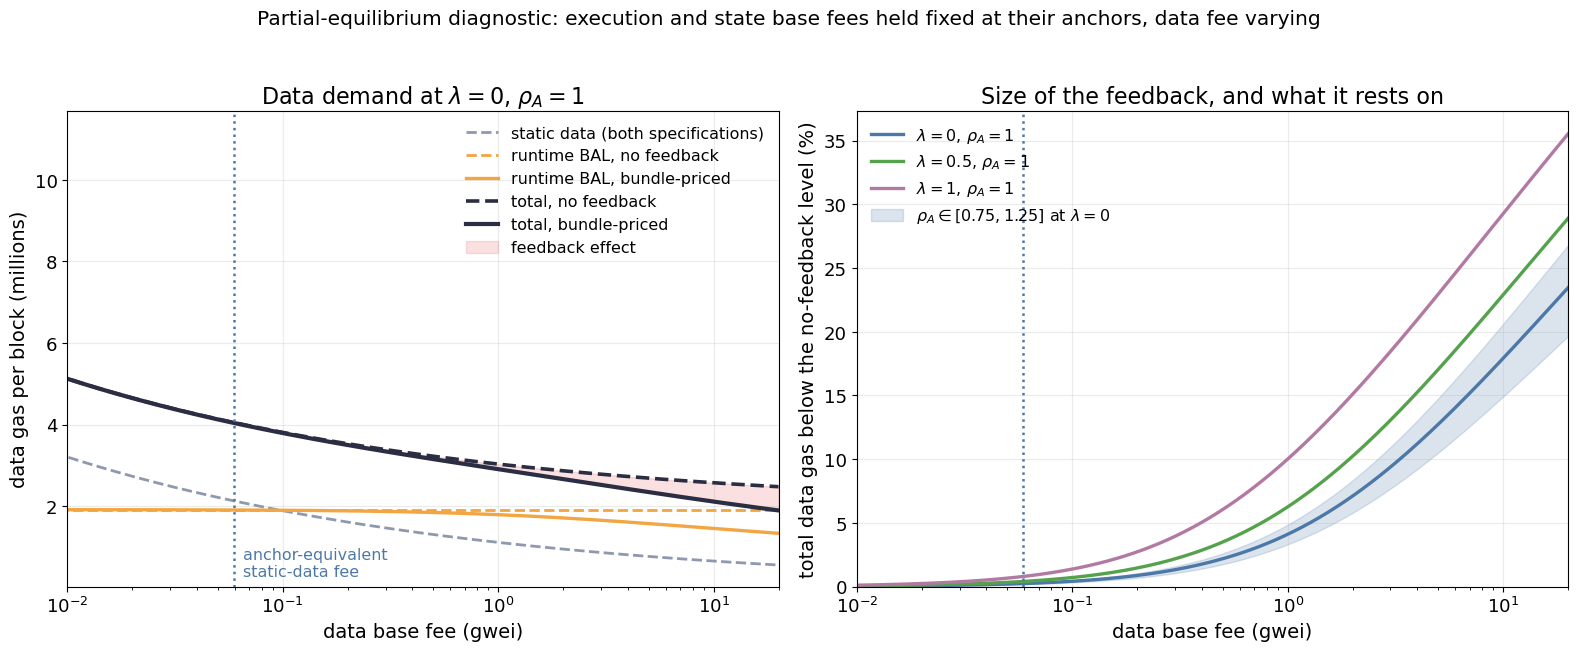

,b_data_gwei,total_no_feedback_M,total_bundle_priced_M,bal_bundle_priced_M,feedback_reduction_pct,bal_reduction_pct
0,0.059166,4.052659,4.043072,1.909513,0.236553,0.499541
1,1.000000,3.034227,2.909633,1.794506,4.106274,6.492297
2,5.000000,2.689874,2.347133,1.576358,12.741927,17.859510
3,20.000000,2.479849,1.898395,1.337646,23.447150,30.298267


wrote data/7999/bal_data_demand_response.csv
wrote plots/bal_data_demand_response_2026-02-01_2026-06-01.png


In [6]:
from scipy.optimize import brentq

g_static_0 = float(metering_anchor["static_data_gas_per_block"])
m_data_static = float(metering_anchor["static_data_metering_multiplier"])

# Central 35-day elasticity vector. Verified against the resource-demand handoff
# when present, with the published values as a reproducible fallback.
CENTRAL_WINDOW = 35
published_central_eps = {
    "execution": 0.12115963781672123,
    "data": 0.22947627499683815,
    "state": 0.33486384705804656,
}
elasticity_path = DATA_DIR / "glamsterdam" / "elasticity_vectors.csv"
if elasticity_path.exists():
    row = pd.read_csv(elasticity_path).set_index("window_days").loc[CENTRAL_WINDOW]
    eps = {
        "execution": float(row["eps_execution"]),
        "data": float(row["eps_data"]),
        "state": float(row["eps_state"]),
    }
    for key, value in published_central_eps.items():
        if not np.isclose(eps[key], value, rtol=1e-9):
            raise AssertionError(f"central elasticity changed for {key}")
else:
    eps = dict(published_central_eps)

p0 = shared_anchor["base_fee_ref_gwei"]
B_EXECUTION = p0 / m_execution      # anchor-equivalent execution fee
B_STATE = p0 / m_state              # anchor-equivalent state fee
B_DATA_0 = p0 / m_data_static       # anchor-equivalent static-data fee


def execution_ratio(b_data, w_execution, rho_A):
    """Realised execution activity relative to its anchor at a given data fee.

    With rho_A != 1 the average BAL intensity depends on realised execution, so
    the ratio solves an implicit equation. Solved in logs, which stays stable at
    the very small fees reached at the left of the sweep.
    """
    log_execution_charge = np.log(m_execution * B_EXECUTION)
    log_p0 = np.log(p0)
    if b_data <= 0.0:
        return float(np.exp(-eps["execution"] * (log_execution_charge - log_p0)))
    log_bal_charge = np.log(w_execution * b_data)

    def log_residual(log_ratio):
        log_price = np.logaddexp(
            log_execution_charge, log_bal_charge + (rho_A - 1.0) * log_ratio
        )
        return log_ratio + eps["execution"] * (log_price - log_p0)

    return float(np.exp(brentq(log_residual, -80.0, 80.0, xtol=1e-13, rtol=1e-13)))


def data_components(b_data, lambda_bal, rho_A, feedback):
    """Static, runtime-BAL and total data gas per block at a candidate data fee."""
    row = intensities[intensities["lambda_bal"].eq(lambda_bal)].iloc[0]
    w_execution = float(row["w_execution"])
    w_state = float(row["w_state"])

    g_static = g_static_0 * (m_data_static * b_data / p0) ** (-eps["data"])

    if feedback:
        r_execution = execution_ratio(b_data, w_execution, rho_A)
        price_state = m_state * B_STATE + w_state * b_data
        q_state = q_state_0 * (price_state / p0) ** (-eps["state"])
    else:
        # Parents ignore the BAL charge, so both stay at their anchors.
        r_execution = 1.0
        q_state = q_state_0

    g_bal = w_execution * q_execution_0 * r_execution ** rho_A + w_state * q_state
    return g_static, g_bal, g_static + g_bal


# The grid runs down to 1e-4 gwei so the vanishing-surcharge check below has
# something to stand on; the panels are limited to the region where the
# feedback is visible.
b_grid = np.logspace(np.log10(1e-4), np.log10(20.0), 400)
PLOT_FEE_MIN = 1e-2

sweep_rows = []
for lambda_bal in (0.0, 0.5, 1.0):
    for rho_A in (0.75, 1.0, 1.25):
        for feedback in (False, True):
            for b_data in b_grid:
                g_static, g_bal, g_total = data_components(
                    b_data, lambda_bal, rho_A, feedback
                )
                sweep_rows.append({
                    "lambda_bal": lambda_bal,
                    "rho_A": rho_A,
                    "specification": "bundle-priced" if feedback else "no feedback",
                    "b_data_gwei": b_data,
                    "static_data_gas": g_static,
                    "runtime_bal_data_gas": g_bal,
                    "total_data_gas": g_total,
                })
sweep = pd.DataFrame(sweep_rows)
sweep.to_csv(OUT_DATA_RESPONSE_CSV, index=False)

# The two specifications must agree as the surcharge vanishes, and the
# no-feedback BAL component must be exactly flat.
low = sweep[np.isclose(sweep["b_data_gwei"], b_grid[0])]
low_central = low[low["lambda_bal"].eq(0.0) & low["rho_A"].eq(1.0)]
assert np.isclose(
    low_central[low_central["specification"].eq("no feedback")]["total_data_gas"].iloc[0],
    low_central[low_central["specification"].eq("bundle-priced")]["total_data_gas"].iloc[0],
    rtol=2e-4,
)
flat = sweep[sweep["specification"].eq("no feedback")]
assert np.allclose(flat["runtime_bal_data_gas"], g_bal_0, rtol=1e-12)


def series_for(lambda_bal, rho_A, specification):
    selected = sweep[
        sweep["lambda_bal"].eq(lambda_bal)
        & sweep["rho_A"].eq(rho_A)
        & sweep["specification"].eq(specification)
    ]
    return selected.set_index("b_data_gwei")


no_fb = series_for(0.0, 1.0, "no feedback")
bundled = series_for(0.0, 1.0, "bundle-priced")

fig, axes = plt.subplots(1, 2, figsize=(16.0, 6.4))

ax = axes[0]
ax.plot(b_grid, no_fb["static_data_gas"] / 1e6, color="#8d99ae", linestyle="--",
        linewidth=2.0, label="static data (both specifications)")
ax.plot(b_grid, no_fb["runtime_bal_data_gas"] / 1e6, color="#f2a541", linestyle="--",
        linewidth=2.0, label="runtime BAL, no feedback")
ax.plot(b_grid, bundled["runtime_bal_data_gas"] / 1e6, color="#f2a541",
        linewidth=2.4, label="runtime BAL, bundle-priced")
ax.plot(b_grid, no_fb["total_data_gas"] / 1e6, color="#2b2d42", linestyle="--",
        linewidth=2.6, label="total, no feedback")
ax.plot(b_grid, bundled["total_data_gas"] / 1e6, color="#2b2d42",
        linewidth=3.0, label="total, bundle-priced")
ax.fill_between(b_grid, bundled["total_data_gas"] / 1e6, no_fb["total_data_gas"] / 1e6,
                color="#e45756", alpha=0.18, label="feedback effect")
ax.axvline(B_DATA_0, color="#4c78a8", linestyle=":", linewidth=1.8)
ax.annotate("anchor-equivalent\nstatic-data fee", xy=(B_DATA_0, 0.015),
            xycoords=("data", "axes fraction"), xytext=(7, 0),
            textcoords="offset points", fontsize=11.5, color="#4c78a8", va="bottom")
ax.set_xscale("log")
ax.set_xlim(PLOT_FEE_MIN, b_grid[-1])
ax.set_xlabel("data base fee (gwei)")
ax.set_ylabel("data gas per block (millions)")
ax.set_title("Data demand at $\\lambda=0$, $\\rho_A=1$")
ax.legend(frameon=False, loc="upper right", fontsize=11.5)
ax.grid(alpha=0.25)

ax = axes[1]
lambda_colors = {0.0: "#4c78a8", 0.5: "#54a24b", 1.0: "#b279a2"}
for lambda_bal, color in lambda_colors.items():
    reduction = 100 * (
        1
        - series_for(lambda_bal, 1.0, "bundle-priced")["total_data_gas"].to_numpy()
        / series_for(lambda_bal, 1.0, "no feedback")["total_data_gas"].to_numpy()
    )
    ax.plot(b_grid, reduction, color=color, linewidth=2.4,
            label=f"$\\lambda={lambda_bal:g}$, $\\rho_A=1$")

rho_band = {}
for rho_A in (0.75, 1.25):
    rho_band[rho_A] = 100 * (
        1
        - series_for(0.0, rho_A, "bundle-priced")["total_data_gas"].to_numpy()
        / series_for(0.0, rho_A, "no feedback")["total_data_gas"].to_numpy()
    )
ax.fill_between(b_grid, rho_band[0.75], rho_band[1.25], color="#4c78a8", alpha=0.20,
                label="$\\rho_A\\in[0.75,1.25]$ at $\\lambda=0$")
ax.axvline(B_DATA_0, color="#4c78a8", linestyle=":", linewidth=1.8)
ax.set_xscale("log")
ax.set_xlim(PLOT_FEE_MIN, b_grid[-1])
ax.set_ylim(bottom=0)
ax.set_xlabel("data base fee (gwei)")
ax.set_ylabel("total data gas below the no-feedback level (%)")
ax.set_title("Size of the feedback, and what it rests on")
ax.legend(frameon=False, loc="upper left", fontsize=11.5)
ax.grid(alpha=0.25)

fig.suptitle(
    "Partial-equilibrium diagnostic: execution and state base fees held fixed "
    "at their anchors, data fee varying",
    fontsize=14.5, y=1.02,
)
fig.tight_layout()
fig.savefig(DATA_RESPONSE_PLOT, dpi=220, bbox_inches="tight")
plt.show()

reference_fees = [B_DATA_0, 1.0, 5.0, 20.0]
summary = []
for b_data in reference_fees:
    _, _, total_nf = data_components(b_data, 0.0, 1.0, feedback=False)
    _, bal_bp, total_bp = data_components(b_data, 0.0, 1.0, feedback=True)
    summary.append({
        "b_data_gwei": b_data,
        "total_no_feedback_M": total_nf / 1e6,
        "total_bundle_priced_M": total_bp / 1e6,
        "bal_bundle_priced_M": bal_bp / 1e6,
        "feedback_reduction_pct": 100 * (1 - total_bp / total_nf),
        "bal_reduction_pct": 100 * (1 - bal_bp / g_bal_0),
    })
summary = pd.DataFrame(summary)
display(summary)
print("wrote", OUT_DATA_RESPONSE_CSV.relative_to(PROJECT_ROOT))
print("wrote", DATA_RESPONSE_PLOT.relative_to(PROJECT_ROOT))


## Sampling uncertainty

The runtime anchor and the three decomposition shares are estimated from 50
deterministically sampled blocks per day, not from the full 120-day population.
The design is stratified by day, with every day observed and blocks sampled
within it, so the sampling error is a within-day quantity.

The interval below resamples blocks with replacement inside each day, 2,000
times, and recomputes each statistic. The anchor is weighted by canonical block
counts exactly as in notebook 01; the shares are unweighted sums over sampled
blocks, matching their point estimates above.

This covers sampling error only. It says nothing about the attribution
assumptions, the capped cold-access matching, or the reverted-frame storage
values the reconstruction cannot see.


In [7]:
N_BOOTSTRAP = 2000
rng = np.random.default_rng(20260807)

att = attribution_blocks.copy()
att["date_key"] = pd.to_datetime(att["date"]).dt.strftime("%Y-%m-%d")
att = att.sort_values(["date_key", "block_number"]).reset_index(drop=True)
day_keys = att["date_key"].drop_duplicates().to_numpy()
n_days = len(day_keys)
per_day = len(att) // n_days
assert n_days == 120 and per_day == 50
assert att.groupby("date_key").size().eq(per_day).all()


def day_matrix(column):
    return att[column].to_numpy(dtype=float).reshape(n_days, per_day)


total_m = day_matrix("bal_runtime_bytes_8279")
component_matrices = {
    "direct_state_share": day_matrix("bal_runtime_bytes_state_8279"),
    "coproduced_share": day_matrix("bal_runtime_bytes_coproduced_state_txs_8279"),
    "nonstate_share": day_matrix("bal_runtime_bytes_nonstate_txs_8279"),
}

# Canonical block counts weight the per-block anchor, matching notebook 01.
daily_panel = pd.read_csv(OUT_DIR / f"xatu_daily_data_metering_{DATE_TAG}.csv")
daily_panel["date_key"] = pd.to_datetime(daily_panel["date"]).dt.strftime("%Y-%m-%d")
block_counts = daily_panel.set_index("date_key").loc[day_keys, "block_count"]
weights = block_counts.to_numpy(dtype=float)
weights = weights / weights.sum()
assert np.isclose(
    (total_m.mean(axis=1) * weights).sum(), RUNTIME_ANCHOR, rtol=1e-9
), "the weighted sample mean must reproduce the notebook-01 anchor"

boot_index = rng.integers(0, per_day, size=(N_BOOTSTRAP, n_days, per_day))
day_rows = np.arange(n_days)[None, :, None]

sampled_total = total_m[day_rows, boot_index]
boot_anchor_bytes = (sampled_total.mean(axis=2) * weights).sum(axis=1)
boot_total_sums = sampled_total.sum(axis=(1, 2))
del sampled_total

boot_draws = {
    "runtime_bal_bytes_per_block": boot_anchor_bytes,
    "runtime_bal_data_gas_per_block": 16.0 * boot_anchor_bytes,
}
for name, matrix in component_matrices.items():
    boot_draws[name] = matrix[day_rows, boot_index].sum(axis=(1, 2)) / boot_total_sums
del boot_index

point_estimates = {
    "runtime_bal_bytes_per_block": RUNTIME_ANCHOR,
    "runtime_bal_data_gas_per_block": RUNTIME_DATA_GAS_16,
    "direct_state_share": STATE_WEIGHT,
    "coproduced_share": COPRODUCED_WEIGHT,
    "nonstate_share": NONSTATE_WEIGHT,
}

sampling_rows = []
for name, draws in boot_draws.items():
    estimate = point_estimates[name]
    standard_error = float(draws.std(ddof=1))
    low, high = np.percentile(draws, [2.5, 97.5])
    sampling_rows.append({
        "quantity": name,
        "estimate": estimate,
        "standard_error": standard_error,
        "ci_low_2p5": float(low),
        "ci_high_97p5": float(high),
        "relative_standard_error_pct": 100 * standard_error / abs(estimate),
    })
sampling = pd.DataFrame(sampling_rows)
sampling["bootstrap_replicates"] = N_BOOTSTRAP
sampling["sampled_blocks"] = n_days * per_day
sampling.to_csv(OUT_SAMPLING_CSV, index=False)

display(sampling)
print("wrote", OUT_SAMPLING_CSV.relative_to(PROJECT_ROOT))


,quantity,estimate,standard_error,ci_low_2p5,ci_high_97p5,relative_standard_error_pct,bootstrap_replicates,sampled_blocks
0,runtime_bal_bytes_per_block,1.199437e+05,661.104682,1.186747e+05,1.212459e+05,0.551179,2000,6000
1,runtime_bal_data_gas_per_block,1.919100e+06,10577.674906,1.898795e+06,1.939934e+06,0.551179,2000,6000
2,direct_state_share,1.139371e-01,0.001414,1.112473e-01,1.168434e-01,1.241346,2000,6000
3,coproduced_share,3.787909e-01,0.001429,3.760502e-01,3.815917e-01,0.377335,2000,6000
4,nonstate_share,5.072720e-01,0.001775,5.037190e-01,5.106057e-01,0.349936,2000,6000


wrote data/7999/bal_sampling_uncertainty.csv
